In [1]:
"""
======
CELL 1
======
"""

# Install required libraries
!pip install kaggle seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
"""
======
CELL 2
======
"""

from google.colab import files
import os

# Upload kaggle.json
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Setup Kaggle API
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!chmod 600 /content/kaggle.json

# Download the dataset
!kaggle datasets download -d zelihayb/sustainable-energy-and-environmental-data
!unzip sustainable-energy-and-environmental-data.zip

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zelihayb/sustainable-energy-and-environmental-data
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/390k [00:00<?, ?B/s]
100% 390k/390k [00:00<00:00, 908MB/s]
Archive:  sustainable-energy-and-environmental-data.zip
  inflating: energy_data_II.csv      


In [7]:
"""
======
CELL 3
======
"""

df = pd.read_csv('energy_data_II.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2926, 54)

Column Names:
['Country Name', 'Country Code', 'Years', 'Access to clean fuels and technologies for cooking (% of population)', 'Access to clean fuels and technologies for cooking, rural (% of rural population)', 'Access to clean fuels and technologies for cooking, urban (% of urban population)', 'Access to electricity (% of population)', 'Access to electricity, rural (% of rural population)', 'Access to electricity, urban (% of urban population)', 'Adjusted savings: energy depletion (% of GNI)', 'Alternative and nuclear energy (% of total energy use)', 'CO2 emissions (kt)', 'CO2 emissions (metric tons per capita)', 'CO2 emissions from electricity and heat production, total (% of total fuel combustion)', 'CO2 emissions from gaseous fuel consumption (% of total)', 'CO2 emissions from gaseous fuel consumption (kt)', 'CO2 emissions from liquid fuel consumption (% of total)', 'CO2 emissions from liquid fuel consumption (kt)', 'CO2 emissions from manufacturing ind

Using 'CO2 emissions (kt)' as the main feature

CO2 emissions (kt) Analysis:
----------------------------------------
Non-null values: 2389
Null values: 537
Data type: float64

Basic Statistics:
count    2.389000e+03
mean     1.204216e+06
std      3.923525e+06
min      0.000000e+00
25%      3.209040e+03
50%      2.762910e+04
75%      2.744667e+05
max      3.556056e+07
Name: CO2 emissions (kt), dtype: float64


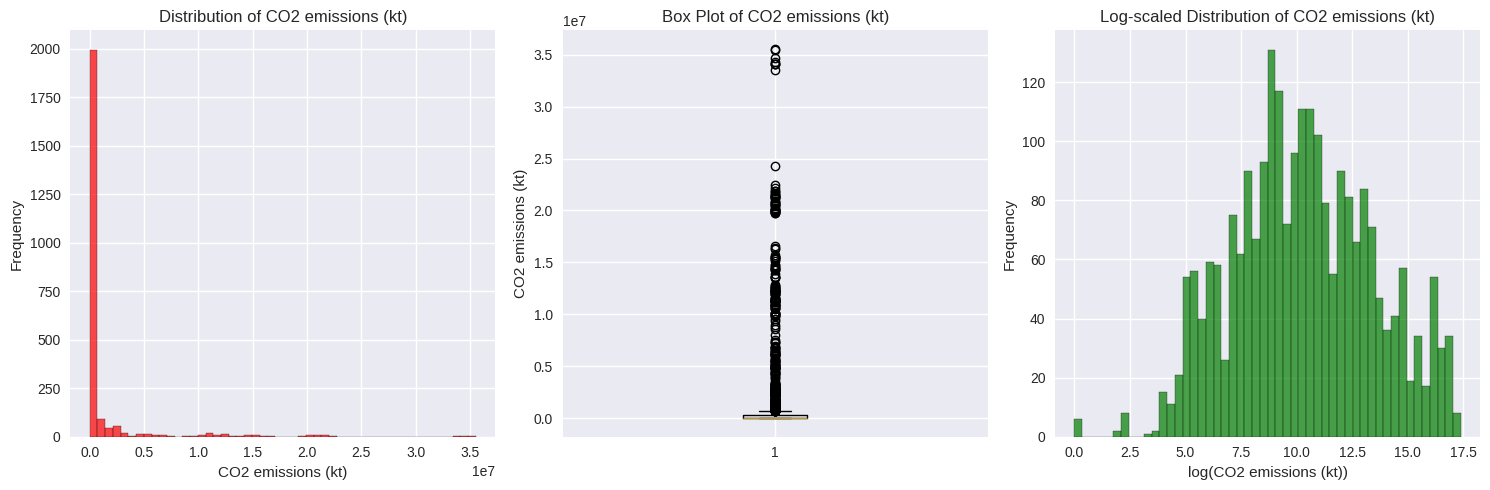


Data cleaning results:
Original dataset: 2926 rows
After removing missing CO2 values: 2389 rows
Rows removed: 537


In [8]:
"""
======
CELL 4
======
"""

if main_feature is None:
    # Manual selection if automatic detection fails
    print("Available columns:")
    for i, col in enumerate(df.columns):
        print(f"{i+1}. {col}")

    col_index = int(input("Enter the number of the CO2 emissions column: ")) - 1
    main_feature = df.columns[col_index]

print(f"Using '{main_feature}' as the main feature")

# Analyze CO2 emissions column
print(f"\n{main_feature} Analysis:")
print("-" * 40)
print(f"Non-null values: {df[main_feature].count()}")
print(f"Null values: {df[main_feature].isnull().sum()}")
print(f"Data type: {df[main_feature].dtype}")
print(f"\nBasic Statistics:")
print(df[main_feature].describe())

# Visualize CO2 emissions distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df[main_feature].dropna(), bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title(f'Distribution of {main_feature}')
plt.xlabel(main_feature)
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.boxplot(df[main_feature].dropna())
plt.title(f'Box Plot of {main_feature}')
plt.ylabel(main_feature)

plt.subplot(1, 3, 3)
# Log scale if values are very large
co2_values = df[main_feature].dropna()
if co2_values.max() > 1000:
    plt.hist(np.log1p(co2_values), bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.title(f'Log-scaled Distribution of {main_feature}')
    plt.xlabel(f'log({main_feature})')
else:
    plt.hist(co2_values, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.title(f'Distribution of {main_feature}')
    plt.xlabel(main_feature)
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Handle missing values in CO2 emissions
df_clean = df.copy()
initial_shape = df_clean.shape[0]
df_clean = df_clean.dropna(subset=[main_feature])
final_shape = df_clean.shape[0]

print(f"\nData cleaning results:")
print(f"Original dataset: {initial_shape} rows")
print(f"After removing missing CO2 values: {final_shape} rows")
print(f"Rows removed: {initial_shape - final_shape}")

In [9]:
"""
======
CELL 5
======
"""

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Remove identifier columns
identifier_cols = ['Year']
if 'Entity' in df_clean.columns:
    identifier_cols.append('Entity')

# Energy and environmental related features (adjust based on actual column names)
energy_related_keywords = [
    'renewable', 'energy', 'electricity', 'power', 'gdp', 'population',
    'fossil', 'nuclear', 'hydro', 'wind', 'solar', 'consumption', 'production',
    'capita', 'intensity'
]

# Select features related to energy and environment
relevant_features = [main_feature]  # Start with CO2 emissions

for col in numerical_cols:
    if col not in identifier_cols and col != main_feature:
        # Check if column name contains energy-related keywords
        if any(keyword.lower() in col.lower() for keyword in energy_related_keywords):
            relevant_features.append(col)

# If we don't have many features, include more numerical columns
if len(relevant_features) < 5:
    for col in numerical_cols:
        if col not in identifier_cols and col not in relevant_features:
            relevant_features.append(col)
            if len(relevant_features) >= 8:  # Limit to 8 features
                break

print(f"Selected features for CO2-focused clustering:")
for i, feature in enumerate(relevant_features, 1):
    print(f"{i}. {feature}")

# Create feature matrix
X = df_clean[relevant_features].copy()
X = X.dropna()

print(f"\nFeature matrix shape: {X.shape}")
print(f"\nFeature correlation with {main_feature}:")
correlations = X.corr()[main_feature].sort_values(key=abs, ascending=False)
print(correlations)

Selected features for CO2-focused clustering:
1. CO2 emissions (kt)
2. Access to clean fuels and technologies for cooking (% of population)
3. Access to clean fuels and technologies for cooking, rural (% of rural population)
4. Access to clean fuels and technologies for cooking, urban (% of urban population)
5. Access to electricity (% of population)
6. Access to electricity, rural (% of rural population)
7. Access to electricity, urban (% of urban population)
8. Adjusted savings: energy depletion (% of GNI)
9. Alternative and nuclear energy (% of total energy use)
10. CO2 emissions (metric tons per capita)
11. CO2 emissions from electricity and heat production, total (% of total fuel combustion)
12. CO2 emissions from gaseous fuel consumption (% of total)
13. CO2 emissions from gaseous fuel consumption (kt)
14. CO2 emissions from liquid fuel consumption (% of total)
15. CO2 emissions from liquid fuel consumption (kt)
16. CO2 emissions from solid fuel consumption (% of total)
17. CO2 e

CO2 Emissions Quartiles:
25th percentile: 17,458
50th percentile (median): 264,681
75th percentile: 2,403,895
Created CO2 per GDP feature using Energy intensity level of primary energy (MJ/$2017 PPP GDP)
Created CO2 per capita feature using Access to clean fuels and technologies for cooking (% of population)

Final feature set for clustering:
1. CO2 emissions (kt)
2. Access to clean fuels and technologies for cooking (% of population)
3. Access to clean fuels and technologies for cooking, rural (% of rural population)
4. Access to clean fuels and technologies for cooking, urban (% of urban population)
5. Access to electricity (% of population)
6. Access to electricity, rural (% of rural population)
7. Access to electricity, urban (% of urban population)
8. Adjusted savings: energy depletion (% of GNI)
9. Alternative and nuclear energy (% of total energy use)
10. CO2 emissions (metric tons per capita)
11. CO2 emissions from electricity and heat production, total (% of total fuel combust

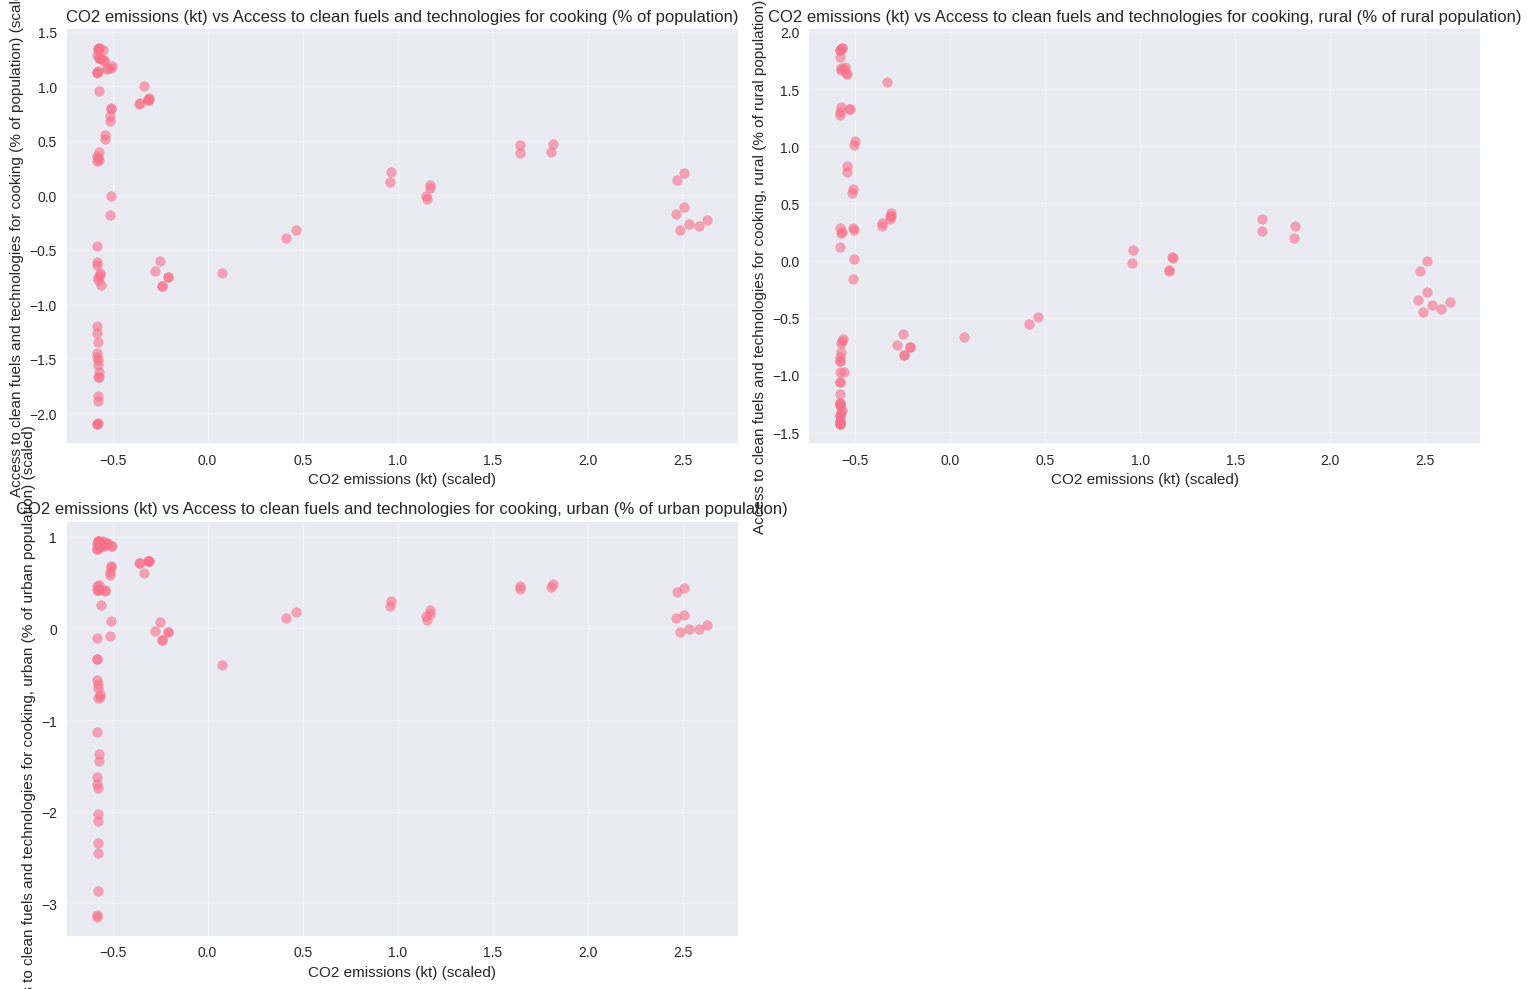

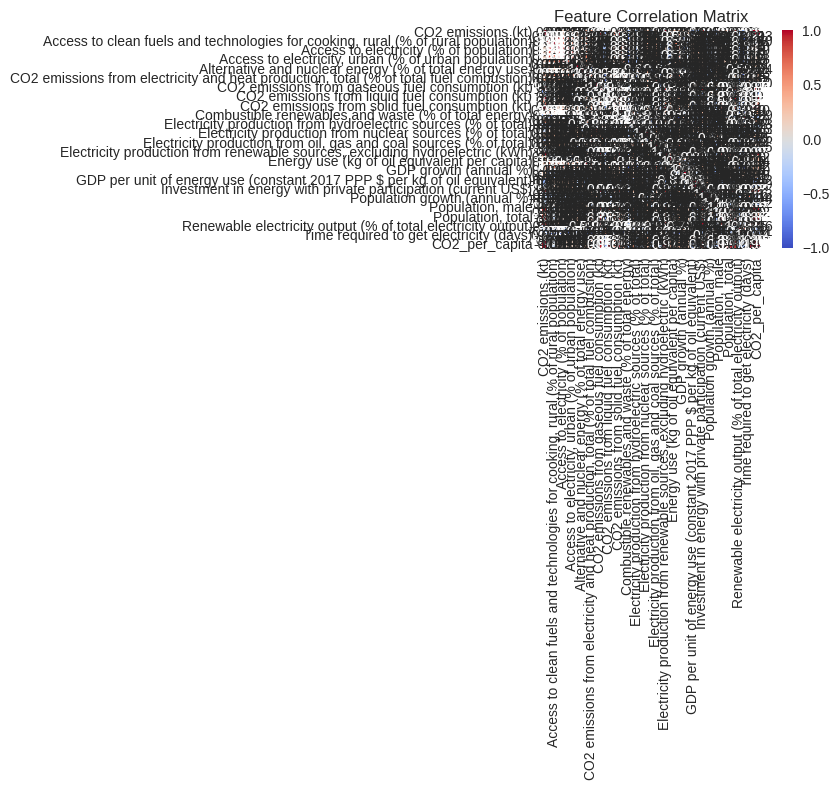

In [10]:
"""
======
CELL 6
======
"""

X_enhanced = X.copy()

# Add CO2 emissions categories for analysis
co2_quartiles = X_enhanced[main_feature].quantile([0.25, 0.5, 0.75])
print(f"CO2 Emissions Quartiles:")
print(f"25th percentile: {co2_quartiles[0.25]:,.0f}")
print(f"50th percentile (median): {co2_quartiles[0.5]:,.0f}")
print(f"75th percentile: {co2_quartiles[0.75]:,.0f}")

# Create CO2 intensity features if we have GDP or population data
gdp_cols = [col for col in X_enhanced.columns if 'gdp' in col.lower()]
pop_cols = [col for col in X_enhanced.columns if 'pop' in col.lower()]

if gdp_cols:
    gdp_col = gdp_cols[0]
    X_enhanced[f'CO2_per_GDP'] = X_enhanced[main_feature] / (X_enhanced[gdp_col] + 1e-10)
    print(f"Created CO2 per GDP feature using {gdp_col}")

if pop_cols:
    pop_col = pop_cols[0]
    X_enhanced[f'CO2_per_capita'] = X_enhanced[main_feature] / (X_enhanced[pop_col] + 1e-10)
    print(f"Created CO2 per capita feature using {pop_col}")

# Scale the features
scaler = StandardScaler()
feature_names = X_enhanced.columns.tolist()
X_scaled = scaler.fit_transform(X_enhanced)

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=X_enhanced.index)

print(f"\nFinal feature set for clustering:")
for i, feature in enumerate(feature_names, 1):
    print(f"{i}. {feature}")

print(f"\nScaled features shape: {X_scaled_df.shape}")

# Visualize feature relationships with CO2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

main_feature_idx = feature_names.index(main_feature)
other_features = [f for f in feature_names if f != main_feature][:3]

for i, feature in enumerate(other_features):
    if i < 4:
        feature_idx = feature_names.index(feature)
        axes[i].scatter(X_scaled[:, main_feature_idx], X_scaled[:, feature_idx], alpha=0.6)
        axes[i].set_xlabel(f'{main_feature} (scaled)')
        axes[i].set_ylabel(f'{feature} (scaled)')
        axes[i].set_title(f'{main_feature} vs {feature}')
        axes[i].grid(True, alpha=0.3)

# Correlation heatmap
if len(axes) > len(other_features):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Show correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = X_enhanced.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

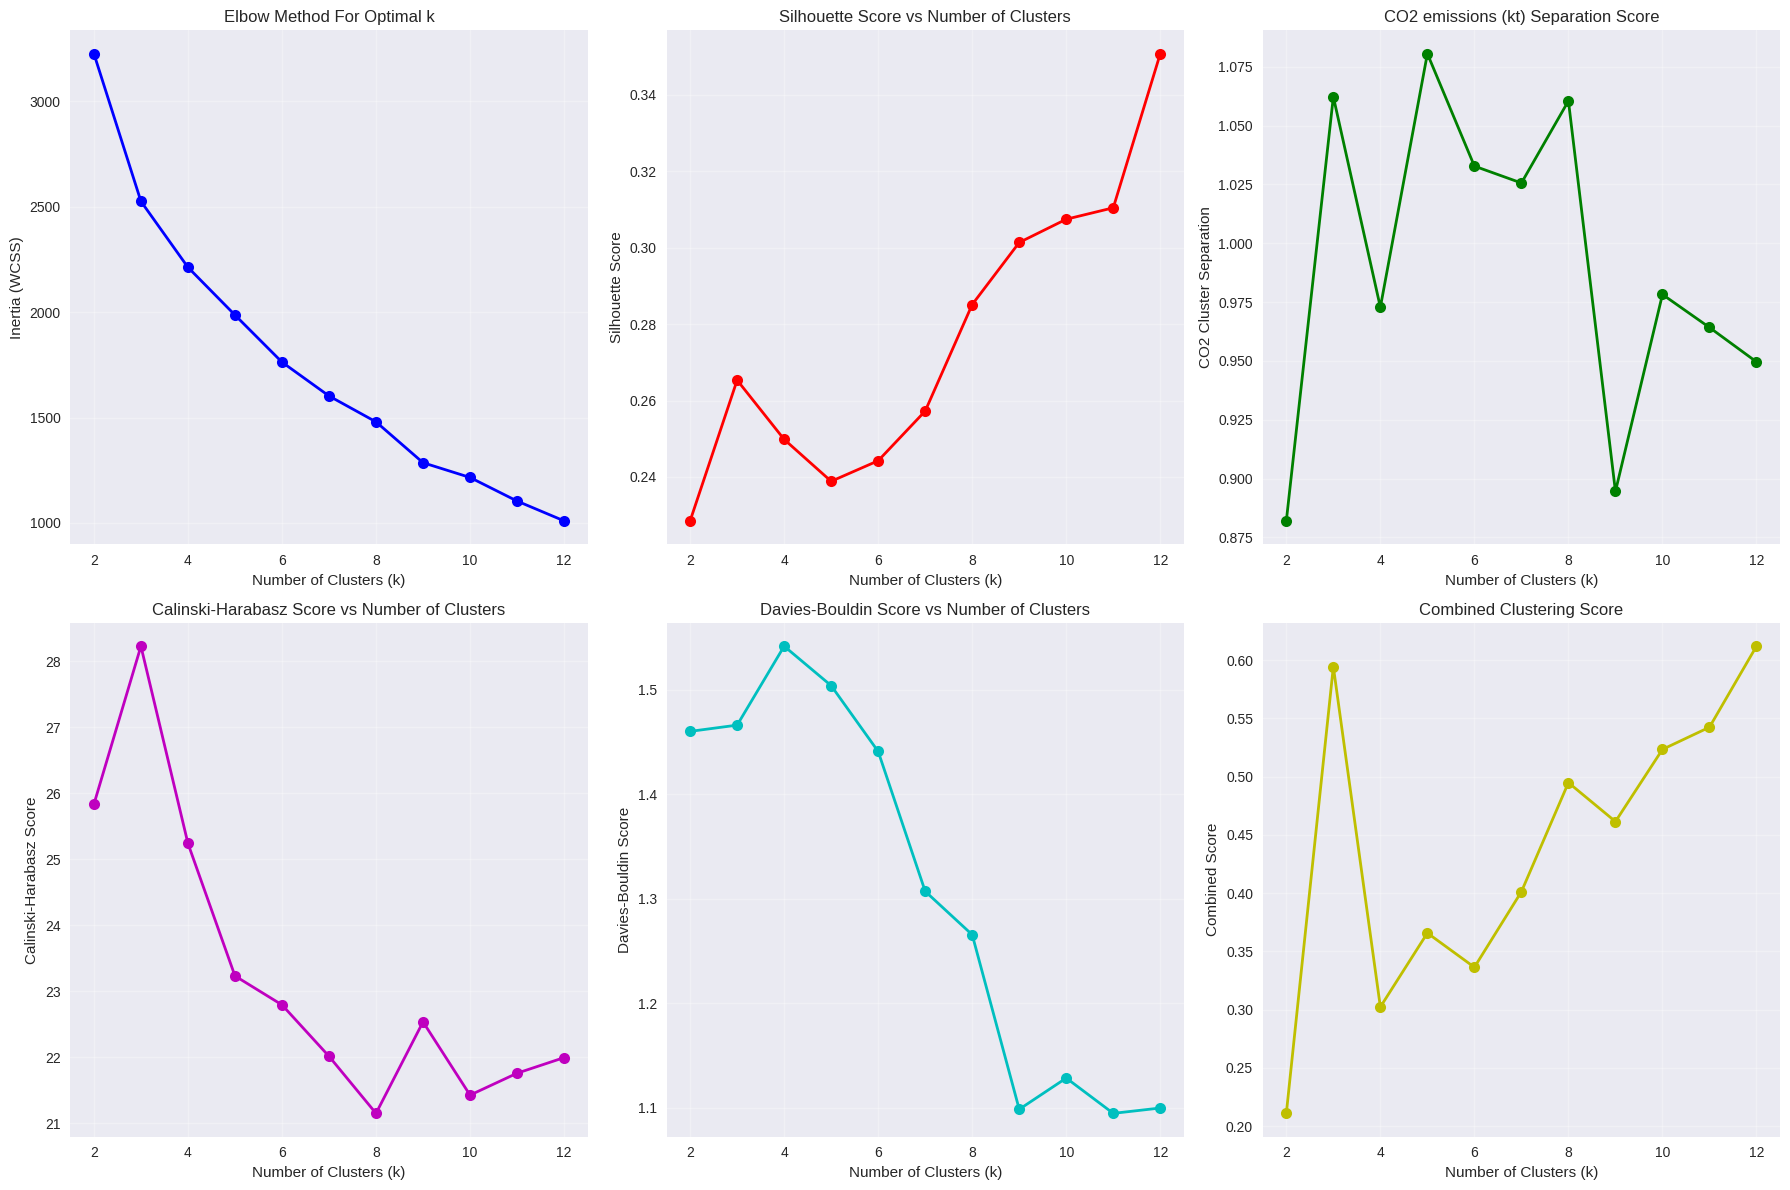

Optimal k recommendations (CO2-focused analysis):
- Silhouette Score: 12 (score: 0.351)
- CO2 Separation: 5 (score: 1.081)
- Combined Score: 12 (score: 0.612)

🎯 Recommended optimal k: 12


In [11]:
"""
======
CELL 7
======
"""

def find_optimal_clusters_co2_focused(X, max_k=10):
    inertias = []
    silhouette_scores = []
    calinski_scores = []
    davies_bouldin_scores = []
    co2_separation_scores = []

    K_range = range(2, max_k + 1)
    main_feature_idx = feature_names.index(main_feature)

    for k in K_range:
        # Fit K-means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)

        # Standard metrics
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X, labels))

        # CO2-specific separation metric
        co2_values = X[:, main_feature_idx]
        cluster_co2_means = []
        for cluster_id in range(k):
            cluster_co2 = co2_values[labels == cluster_id]
            if len(cluster_co2) > 0:
                cluster_co2_means.append(np.mean(cluster_co2))

        # Calculate separation between CO2 cluster means
        if len(cluster_co2_means) > 1:
            co2_separation = np.std(cluster_co2_means)
        else:
            co2_separation = 0
        co2_separation_scores.append(co2_separation)

    return K_range, inertias, silhouette_scores, calinski_scores, davies_bouldin_scores, co2_separation_scores

# Find optimal clusters
K_range, inertias, silhouette_scores, calinski_scores, davies_bouldin_scores, co2_separation_scores = find_optimal_clusters_co2_focused(X_scaled, max_k=12)

# Plot results with CO2 focus
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Elbow Method
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_title('Elbow Method For Optimal k')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia (WCSS)')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score
axes[0, 1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_title('Silhouette Score vs Number of Clusters')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].grid(True, alpha=0.3)

# CO2 Separation Score
axes[0, 2].plot(K_range, co2_separation_scores, 'go-', linewidth=2, markersize=8)
axes[0, 2].set_title(f'{main_feature} Separation Score')
axes[0, 2].set_xlabel('Number of Clusters (k)')
axes[0, 2].set_ylabel('CO2 Cluster Separation')
axes[0, 2].grid(True, alpha=0.3)

# Calinski-Harabasz Score
axes[1, 0].plot(K_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 0].set_title('Calinski-Harabasz Score vs Number of Clusters')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin Score
axes[1, 1].plot(K_range, davies_bouldin_scores, 'co-', linewidth=2, markersize=8)
axes[1, 1].set_title('Davies-Bouldin Score vs Number of Clusters')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].grid(True, alpha=0.3)

# Combined Score
combined_scores = []
for i in range(len(K_range)):
    # Normalize scores and combine (higher is better for most metrics)
    norm_silhouette = (silhouette_scores[i] - min(silhouette_scores)) / (max(silhouette_scores) - min(silhouette_scores))
    norm_calinski = (calinski_scores[i] - min(calinski_scores)) / (max(calinski_scores) - min(calinski_scores))
    norm_davies = 1 - (davies_bouldin_scores[i] - min(davies_bouldin_scores)) / (max(davies_bouldin_scores) - min(davies_bouldin_scores))
    norm_co2_sep = (co2_separation_scores[i] - min(co2_separation_scores)) / (max(co2_separation_scores) - min(co2_separation_scores)) if max(co2_separation_scores) > min(co2_separation_scores) else 0

    combined = (norm_silhouette + norm_calinski + norm_davies + norm_co2_sep) / 4
    combined_scores.append(combined)

axes[1, 2].plot(K_range, combined_scores, 'yo-', linewidth=2, markersize=8)
axes[1, 2].set_title('Combined Clustering Score')
axes[1, 2].set_xlabel('Number of Clusters (k)')
axes[1, 2].set_ylabel('Combined Score')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print recommendations
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
optimal_k_combined = K_range[np.argmax(combined_scores)]
optimal_k_co2_sep = K_range[np.argmax(co2_separation_scores)]

print(f"Optimal k recommendations (CO2-focused analysis):")
print(f"- Silhouette Score: {optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"- CO2 Separation: {optimal_k_co2_sep} (score: {max(co2_separation_scores):.3f})")
print(f"- Combined Score: {optimal_k_combined} (score: {max(combined_scores):.3f})")

# Suggest final optimal k
suggested_k = optimal_k_combined
print(f"\n🎯 Recommended optimal k: {suggested_k}")

In [12]:
"""
======
CELL 8
======
"""

optimal_k = suggested_k  # You can adjust this if needed

print(f"Applying K-means clustering with {optimal_k} clusters...")

# Apply K-means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add results to dataframe
df_clustered = df_clean.loc[X_enhanced.index].copy()
df_clustered['Cluster'] = cluster_labels

# Add scaled features for analysis
for i, feature_name in enumerate(feature_names):
    df_clustered[f'{feature_name}_scaled'] = X_scaled[:, i]

print(f"✅ K-means clustering completed!")

# Analyze clusters with CO2 focus
print(f"\n📊 Cluster Distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"Cluster {cluster_id}: {count:,} data points ({percentage:.1f}%)")

# CO2 emissions analysis by cluster
print(f"\n🌍 {main_feature} Analysis by Cluster:")
co2_stats = df_clustered.groupby('Cluster')[main_feature].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
print(co2_stats)

# Calculate clustering quality metrics
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_calinski = calinski_harabasz_score(X_scaled, cluster_labels)
final_davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)

print(f"\n📈 Final Clustering Quality Metrics:")
print(f"- Silhouette Score: {final_silhouette:.3f}")
print(f"- Calinski-Harabasz Score: {final_calinski:.1f}")
print(f"- Davies-Bouldin Score: {final_davies_bouldin:.3f}")

Applying K-means clustering with 12 clusters...
✅ K-means clustering completed!

📊 Cluster Distribution:
Cluster 0: 6 data points (6.7%)
Cluster 1: 10 data points (11.2%)
Cluster 2: 17 data points (19.1%)
Cluster 3: 8 data points (9.0%)
Cluster 4: 3 data points (3.4%)
Cluster 5: 10 data points (11.2%)
Cluster 6: 2 data points (2.2%)
Cluster 7: 10 data points (11.2%)
Cluster 8: 9 data points (10.1%)
Cluster 9: 2 data points (2.2%)
Cluster 10: 3 data points (3.4%)
Cluster 11: 9 data points (10.1%)

🌍 CO2 emissions (kt) Analysis by Cluster:
         count         mean         std          min          max
Cluster                                                          
0            6     12701.08     3275.80      8692.40     17458.30
1           10   3098172.14  2096901.02    145993.70   6781898.69
2           17    661727.79   766845.77      4795.40   1760980.10
3            8  20129416.52   371405.80  19740108.91  20808546.94
4            3      7154.70     4632.99      4150.50     124

🔍 DETAILED CO2 CLUSTER ANALYSIS

🏷️  CLUSTER 0 PROFILE
------------------------------
📊 CO2 Emissions Statistics:
   Mean: 12,701 kt
   Median: 13,480 kt
   Std Dev: 3,276 kt
   Category: Low

🔧 Key Features (deviation from global mean):
   Combustible renewables and waste (% of total energy): ↑ 114.1% above average
   Electricity production from nuclear sources (% of total): ↓ 100.0% below average
   CO2 emissions from solid fuel consumption (kt): ↓ 100.0% below average
   Electricity production from renewable sources, excluding hydroelectric (kWh): ↓ 99.9% below average
   CO2 emissions (kt): ↓ 99.7% below average

🏷️  CLUSTER 1 PROFILE
------------------------------
📊 CO2 Emissions Statistics:
   Mean: 3,098,172 kt
   Median: 2,308,629 kt
   Std Dev: 2,096,901 kt
   Category: Very High

🔧 Key Features (deviation from global mean):
   Population density (people per sq. km of land area): ↑ 105.3% above average
   Population, male: ↑ 87.0% above average
   Population, total: ↑ 84.9% ab

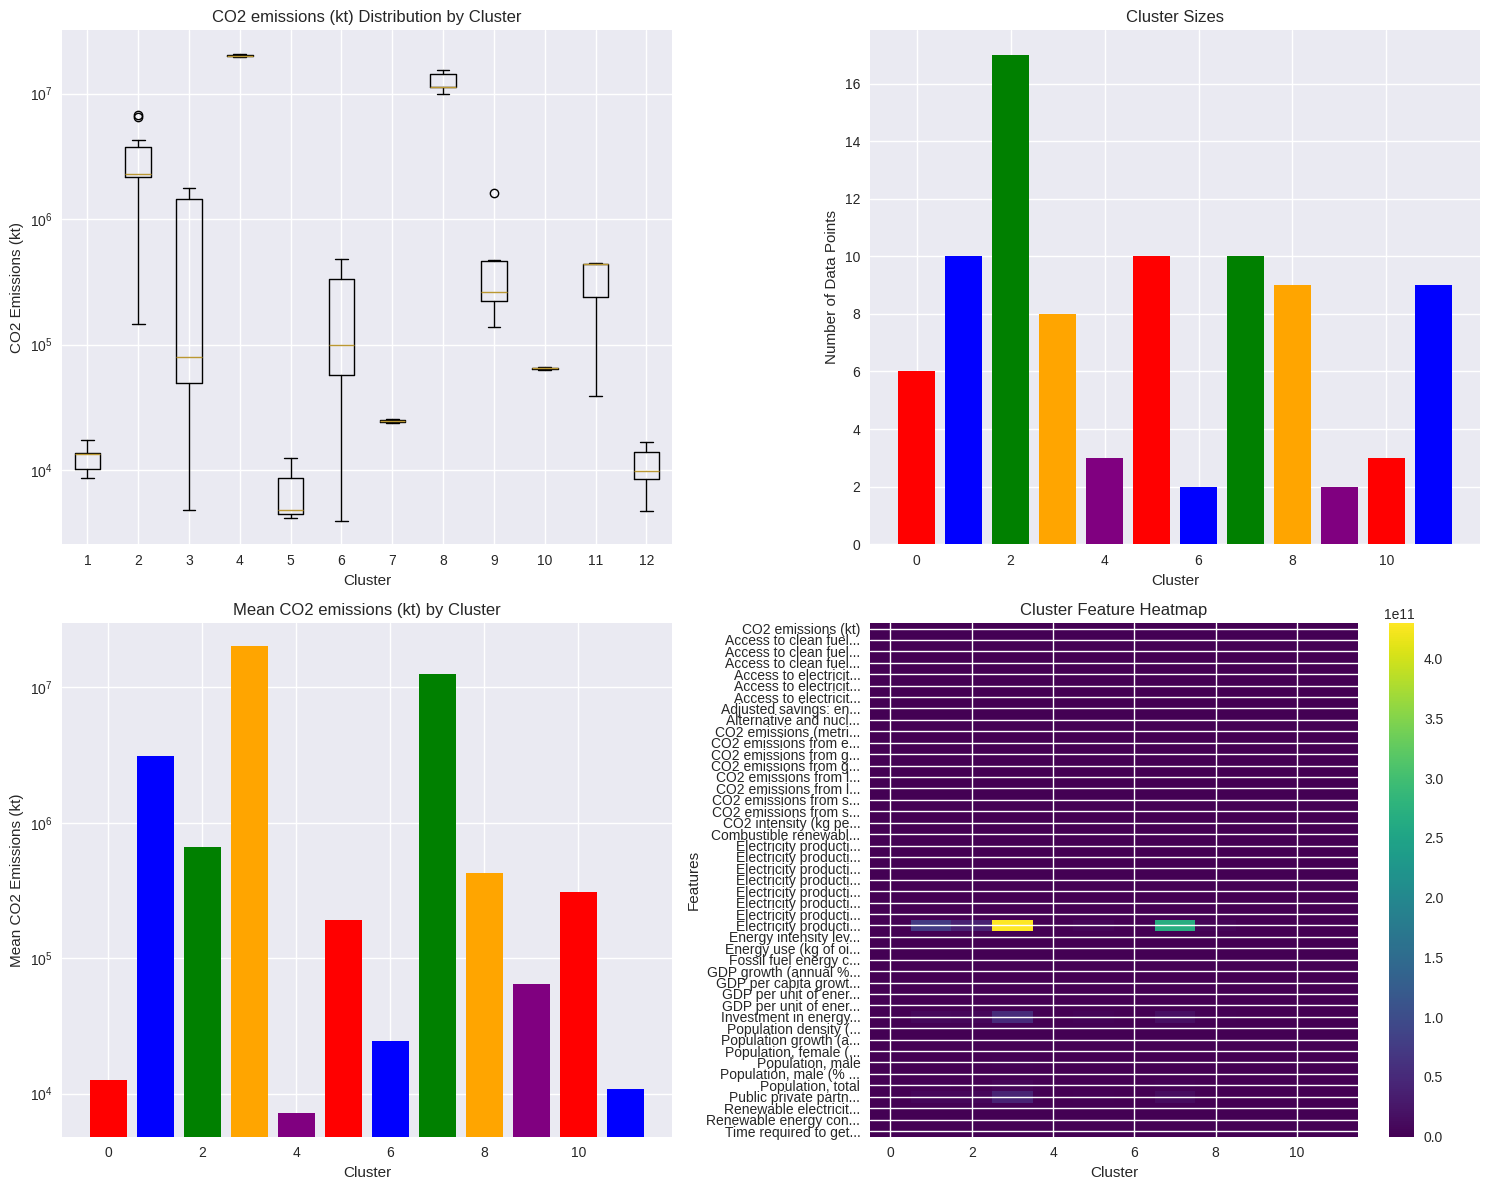


📋 CLUSTER SUMMARY TABLE:
    Cluster  Size      CO2_Mean CO2_Category  \
0         0     6  1.270108e+04          Low   
1         1    10  3.098172e+06    Very High   
2         2    17  6.617278e+05         High   
3         3     8  2.012942e+07      Extreme   
4         4     3  7.154700e+03     Very Low   
5         5    10  1.919226e+05       Medium   
6         6     2  2.467840e+04       Medium   
7         7    10  1.250784e+07    Very High   
8         8     9  4.286341e+05         High   
9         9     2  6.463940e+04       Medium   
10       10     3  3.081802e+05         High   
11       11     9  1.090716e+04          Low   

                                Top_Feature_Deviation  
0   (Combustible renewables and waste (% of total ...  
1   (Population density (people per sq. km of land...  
2   (Alternative and nuclear energy (% of total en...  
3   (CO2 emissions from gaseous fuel consumption (...  
4   (Combustible renewables and waste (% of total ...  
5   (Electric

In [15]:
"""
======
CELL 9
======
"""

print("🔍 DETAILED CO2 CLUSTER ANALYSIS")
print("=" * 50)

# Create CO2 emission categories
co2_percentiles = df_clustered[main_feature].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

def categorize_co2_level(value):
    if value <= co2_percentiles[0.1]:
        return "Very Low"
    elif value <= co2_percentiles[0.25]:
        return "Low"
    elif value <= co2_percentiles[0.5]:
        return "Medium"
    elif value <= co2_percentiles[0.75]:
        return "High"
    elif value <= co2_percentiles[0.9]:
        return "Very High"
    else:
        return "Extreme"

# Analyze each cluster
cluster_profiles = []

for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]

    print(f"\n🏷️  CLUSTER {cluster_id} PROFILE")
    print("-" * 30)

    # CO2 statistics
    co2_mean = cluster_data[main_feature].mean()
    co2_std = cluster_data[main_feature].std()
    co2_median = cluster_data[main_feature].median()

    print(f"📊 CO2 Emissions Statistics:")
    print(f"   Mean: {co2_mean:,.0f} kt")
    print(f"   Median: {co2_median:,.0f} kt")
    print(f"   Std Dev: {co2_std:,.0f} kt")
    print(f"   Category: {categorize_co2_level(co2_mean)}")

    # Feature characteristics - Fixed section
    print(f"\n🔧 Key Features (deviation from global mean):")

    # Only use features that actually exist in the DataFrame
    valid_features = [col for col in feature_names if col in df_clustered.columns]

    if valid_features:
        cluster_means = cluster_data[valid_features].mean()
        global_means = df_clustered[valid_features].mean()

        deviations = []
        for feature in valid_features:
            if global_means[feature] != 0:
                deviation = ((cluster_means[feature] - global_means[feature]) / global_means[feature]) * 100
            else:
                deviation = 0
            deviations.append((feature, deviation))

        # Sort by absolute deviation
        deviations.sort(key=lambda x: abs(x[1]), reverse=True)

        for feature, deviation in deviations[:5]:
            direction = "↑" if deviation > 0 else "↓"
            print(f"   {feature}: {direction} {abs(deviation):.1f}% {'above' if deviation > 0 else 'below'} average")
    else:
        print("   No valid features found for analysis")

    # Sample countries/entities if available
    if 'Entity' in cluster_data.columns:
        sample_entities = cluster_data['Entity'].drop_duplicates().head(5).tolist()
        print(f"\n🌎 Sample Entities: {', '.join(sample_entities)}")

    # Store profile for summary
    cluster_profiles.append({
        'Cluster': cluster_id,
        'Size': len(cluster_data),
        'CO2_Mean': co2_mean,
        'CO2_Category': categorize_co2_level(co2_mean),
        'Top_Feature_Deviation': deviations[0] if deviations and valid_features else ('None', 0)
    })

# Create cluster comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# CO2 emissions by cluster (box plot)
axes[0, 0].boxplot([df_clustered[df_clustered['Cluster'] == i][main_feature].dropna()
                    for i in range(optimal_k)])
axes[0, 0].set_title(f'{main_feature} Distribution by Cluster')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('CO2 Emissions (kt)')
axes[0, 0].set_yscale('log')  # Log scale for better visualization

# Cluster sizes
cluster_sizes = [len(df_clustered[df_clustered['Cluster'] == i]) for i in range(optimal_k)]
axes[0, 1].bar(range(optimal_k), cluster_sizes, color=['red', 'blue', 'green', 'orange', 'purple'][:optimal_k])
axes[0, 1].set_title('Cluster Sizes')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Data Points')

# CO2 means by cluster
co2_means = [df_clustered[df_clustered['Cluster'] == i][main_feature].mean() for i in range(optimal_k)]
axes[1, 0].bar(range(optimal_k), co2_means, color=['red', 'blue', 'green', 'orange', 'purple'][:optimal_k])
axes[1, 0].set_title(f'Mean {main_feature} by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Mean CO2 Emissions (kt)')
axes[1, 0].set_yscale('log')

# Feature importance heatmap - Fixed section
if valid_features:
    cluster_means_matrix = df_clustered.groupby('Cluster')[valid_features].mean()
    im = axes[1, 1].imshow(cluster_means_matrix.T, cmap='viridis', aspect='auto')
    axes[1, 1].set_title('Cluster Feature Heatmap')
    axes[1, 1].set_xlabel('Cluster')
    axes[1, 1].set_ylabel('Features')
    axes[1, 1].set_yticks(range(len(valid_features)))
    axes[1, 1].set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in valid_features])

    # Add colorbar
    plt.colorbar(im, ax=axes[1, 1])
else:
    axes[1, 1].text(0.5, 0.5, 'No valid features\nfor heatmap',
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Cluster Feature Heatmap - No Data')

plt.tight_layout()
plt.show()

# Summary table
profile_df = pd.DataFrame(cluster_profiles)
print(f"\n📋 CLUSTER SUMMARY TABLE:")
print(profile_df)

# Optional: Print available vs requested features for debugging
print(f"\n🔍 FEATURE ANALYSIS:")
print(f"Requested features: {len(feature_names)}")
print(f"Available features: {len(valid_features)}")
if len(valid_features) < len(feature_names):
    missing_features = [col for col in feature_names if col not in df_clustered.columns]
    print(f"Missing features: {missing_features}")


🎨 Creating advanced visualizations...


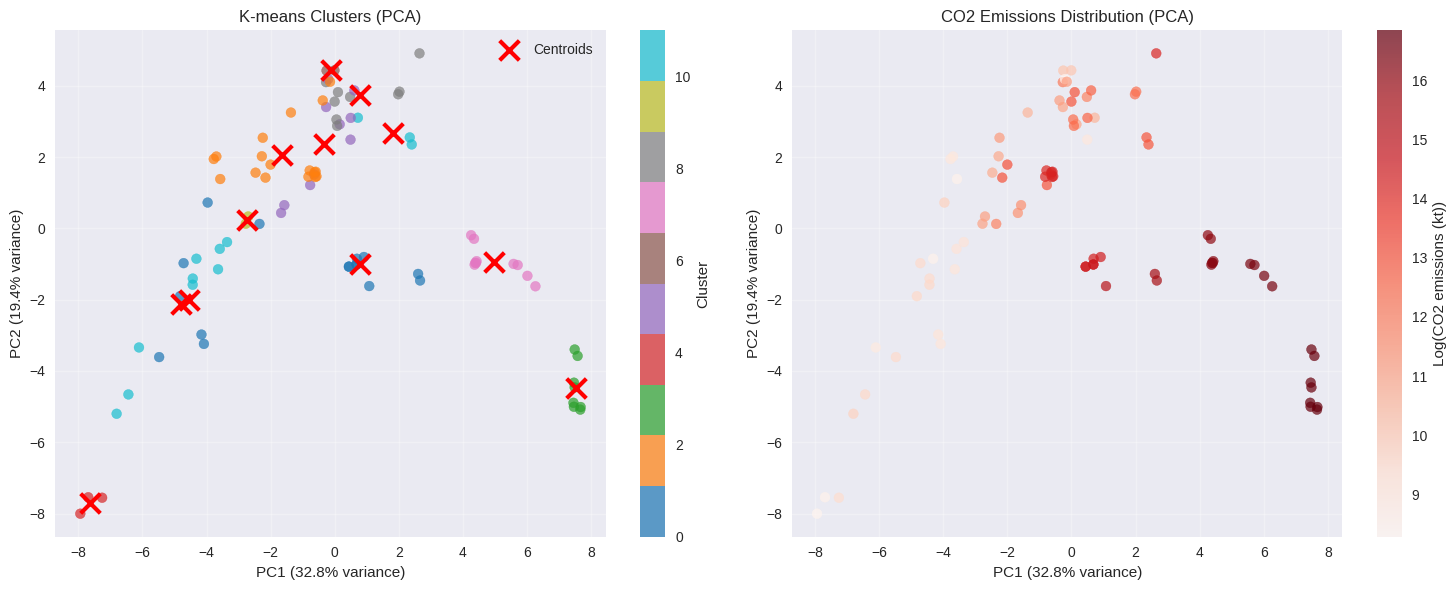

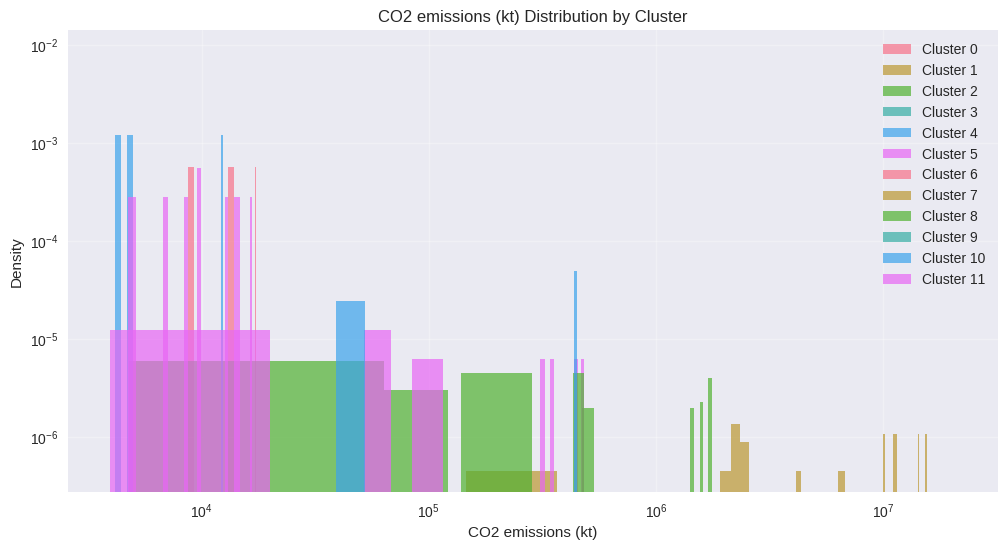

In [16]:
"""
=======
CELL 10
=======
"""

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

# Create enhanced plot dataframe
plot_df = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'Cluster': cluster_labels,
    'CO2_Emissions': df_clustered[main_feature].values,
    'CO2_Log': np.log1p(df_clustered[main_feature].values)
})

# Add entity names if available
if 'Entity' in df_clustered.columns:
    plot_df['Entity'] = df_clustered['Entity'].values

print("🎨 Creating advanced visualizations...")

# 3D Scatter plot colored by CO2 emissions
fig = px.scatter_3d(
    plot_df,
    x='PC1', y='PC2', z='PC3',
    color='CO2_Log',
    hover_data=['CO2_Emissions', 'Cluster'] + (['Entity'] if 'Entity' in plot_df.columns else []),
    title=f'3D PCA View - Colored by {main_feature} (Log Scale)',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]:.1%} var)',
        'CO2_Log': f'Log({main_feature})'
    },
    color_continuous_scale='Viridis'
)
fig.update_layout(height=600)
fig.show()

# 2D PCA with cluster boundaries
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(15, 6))

# Left plot: Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels,
                     cmap='tab10', alpha=0.7, s=50)
plt.colorbar(scatter, label='Cluster')

# Plot cluster centers
centers_2d = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', marker='x',
           s=200, linewidths=3, label='Centroids')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-means Clusters (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot: CO2 emissions
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=np.log1p(df_clustered[main_feature]),
                     cmap='Reds', alpha=0.7, s=50)
plt.colorbar(scatter, label=f'Log({main_feature})')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'CO2 Emissions Distribution (PCA)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interactive scatter matrix for key features
if len(feature_names) >= 4:
    key_features = [main_feature] + [f for f in feature_names if f != main_feature][:3]

    scatter_df = df_clustered[key_features + ['Cluster']].copy()
    if 'Entity' in df_clustered.columns:
        scatter_df['Entity'] = df_clustered['Entity']

    fig = px.scatter_matrix(
        scatter_df,
        dimensions=key_features,
        color='Cluster',
        hover_data=['Entity'] if 'Entity' in scatter_df.columns else None,
        title=f'Feature Relationships Matrix - CO2 Focused'
    )
    fig.update_layout(height=800)
    fig.show()

# CO2 emissions ranking by cluster
plt.figure(figsize=(12, 6))
for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    co2_values = cluster_data[main_feature].values
    plt.hist(co2_values, bins=30, alpha=0.7, label=f'Cluster {cluster_id}',
             density=True)

plt.xlabel(f'{main_feature}')
plt.ylabel('Density')
plt.title(f'{main_feature} Distribution by Cluster')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
"""
=======
CELL 11
=======
"""

from scipy import stats
from scipy.stats import kruskal, chi2_contingency

print("📊 STATISTICAL VALIDATION OF CO2 CLUSTERS")
print("=" * 50)

# 1. ANOVA test for CO2 emissions across clusters
cluster_groups_co2 = [df_clustered[df_clustered['Cluster'] == i][main_feature].dropna()
                      for i in range(optimal_k)]

# Remove empty groups
cluster_groups_co2 = [group for group in cluster_groups_co2 if len(group) > 0]

if len(cluster_groups_co2) >= 2:
    f_stat_co2, p_value_co2 = stats.f_oneway(*cluster_groups_co2)
    print(f"🎯 {main_feature} ANOVA Results:")
    print(f"   F-statistic: {f_stat_co2:.3f}")
    print(f"   p-value: {p_value_co2:.2e}")
    if p_value_co2 < 0.001:
        print("   ✅ Highly significant difference in CO2 emissions across clusters")
    elif p_value_co2 < 0.05:
        print("   ✅ Significant difference in CO2 emissions across clusters")
    else:
        print("   ❌ No significant difference in CO2 emissions across clusters")

# 2. Kruskal-Wallis test (non-parametric alternative)
h_stat, p_value_kw = kruskal(*cluster_groups_co2)
print(f"\n🔬 Kruskal-Wallis Test (Non-parametric):")
print(f"   H-statistic: {h_stat:.3f}")
print(f"   p-value: {p_value_kw:.2e}")

# 3. Post-hoc pairwise comparisons for CO2 emissions
print(f"\n🔍 Pairwise CO2 Emissions Comparisons:")
from itertools import combinations

for i, j in combinations(range(optimal_k), 2):
    group_i = df_clustered[df_clustered['Cluster'] == i][main_feature].dropna()
    group_j = df_clustered[df_clustered['Cluster'] == j][main_feature].dropna()

    if len(group_i) > 0 and len(group_j) > 0:
        # Mann-Whitney U test
        statistic, p_value = stats.mannwhitneyu(group_i, group_j, alternative='two-sided')
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

        mean_i = group_i.mean()
        mean_j = group_j.mean()

        print(f"   Cluster {i} vs {j}: p={p_value:.3f} {significance} "
              f"(means: {mean_i:,.0f} vs {mean_j:,.0f})")

# 4. Feature importance in cluster separation - FIXED SECTION
print(f"\n⚖️  FEATURE IMPORTANCE IN CLUSTER FORMATION:")
feature_importance_scores = []

# Check which features actually exist in the DataFrame
valid_features = [col for col in feature_names if col in df_clustered.columns]

if valid_features:
    print(f"   Analyzing {len(valid_features)} valid features out of {len(feature_names)} requested")

    for feature in valid_features:
        cluster_groups_feature = [df_clustered[df_clustered['Cluster'] == i][feature].dropna()
                                 for i in range(optimal_k)]
        cluster_groups_feature = [group for group in cluster_groups_feature if len(group) > 0]

        if len(cluster_groups_feature) >= 2:
            try:
                f_stat, p_value = stats.f_oneway(*cluster_groups_feature)
                feature_importance_scores.append((feature, f_stat, p_value))
            except:
                feature_importance_scores.append((feature, 0, 1))

    # Sort by F-statistic
    feature_importance_scores.sort(key=lambda x: x[1], reverse=True)

    print("   Top features distinguishing clusters:")
    for feature, f_stat, p_value in feature_importance_scores[:8]:
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"   {feature}: F={f_stat:.2f}, p={p_value:.3f} {significance}")
else:
    print("   ⚠️  No valid features found for importance analysis")
    # If no valid features from feature_names, use all numeric columns except cluster and main_feature
    numeric_cols = df_clustered.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['Cluster', main_feature]]

    if numeric_cols:
        print(f"   Using all available numeric columns: {numeric_cols}")
        for feature in numeric_cols:
            cluster_groups_feature = [df_clustered[df_clustered['Cluster'] == i][feature].dropna()
                                     for i in range(optimal_k)]
            cluster_groups_feature = [group for group in cluster_groups_feature if len(group) > 0]

            if len(cluster_groups_feature) >= 2:
                try:
                    f_stat, p_value = stats.f_oneway(*cluster_groups_feature)
                    feature_importance_scores.append((feature, f_stat, p_value))
                except:
                    feature_importance_scores.append((feature, 0, 1))

        # Sort by F-statistic
        feature_importance_scores.sort(key=lambda x: x[1], reverse=True)

        print("   Top features distinguishing clusters:")
        for feature, f_stat, p_value in feature_importance_scores[:8]:
            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
            print(f"   {feature}: F={f_stat:.2f}, p={p_value:.3f} {significance}")

# 5. Cluster stability analysis
print(f"\n🔄 CLUSTER STABILITY ANALYSIS:")

# Bootstrap resampling to test cluster stability
def bootstrap_clustering(X, n_bootstrap=50, sample_ratio=0.8):
    n_samples = X.shape[0]
    stability_scores = []

    for _ in range(n_bootstrap):
        # Random sample
        indices = np.random.choice(n_samples, int(n_samples * sample_ratio), replace=False)
        X_bootstrap = X[indices]

        # Cluster
        kmeans_bootstrap = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        labels_bootstrap = kmeans_bootstrap.fit_predict(X_bootstrap)

        # Calculate silhouette score
        if len(np.unique(labels_bootstrap)) > 1:
            score = silhouette_score(X_bootstrap, labels_bootstrap)
            stability_scores.append(score)

    return stability_scores

stability_scores = bootstrap_clustering(X_scaled, n_bootstrap=30)
mean_stability = np.mean(stability_scores)
std_stability = np.std(stability_scores)

print(f"   Bootstrap Silhouette Scores:")
print(f"   Mean: {mean_stability:.3f} ± {std_stability:.3f}")
print(f"   Range: [{min(stability_scores):.3f}, {max(stability_scores):.3f}]")

if std_stability < 0.1:
    print("   ✅ Clusters are highly stable")
elif std_stability < 0.2:
    print("   ✅ Clusters are moderately stable")
else:
    print("   ⚠️  Clusters show some instability")

# Optional: Print feature analysis for debugging
if len(feature_names) > len(valid_features):
    missing_features = [col for col in feature_names if col not in df_clustered.columns]
    print(f"\n🔍 FEATURE DEBUG INFO:")
    print(f"   Requested features: {feature_names}")
    print(f"   Missing features: {missing_features}")
    print(f"   Available columns: {list(df_clustered.columns)}")


📊 STATISTICAL VALIDATION OF CO2 CLUSTERS
🎯 CO2 emissions (kt) ANOVA Results:
   F-statistic: 265.966
   p-value: 1.76e-56
   ✅ Highly significant difference in CO2 emissions across clusters

🔬 Kruskal-Wallis Test (Non-parametric):
   H-statistic: 71.074
   p-value: 7.63e-11

🔍 Pairwise CO2 Emissions Comparisons:
   Cluster 0 vs 1: p=0.001 ** (means: 12,701 vs 3,098,172)
   Cluster 0 vs 2: p=0.020 * (means: 12,701 vs 661,728)
   Cluster 0 vs 3: p=0.001 *** (means: 12,701 vs 20,129,417)
   Cluster 0 vs 4: p=0.095 ns (means: 12,701 vs 7,155)
   Cluster 0 vs 5: p=0.056 ns (means: 12,701 vs 191,923)
   Cluster 0 vs 6: p=0.071 ns (means: 12,701 vs 24,678)
   Cluster 0 vs 7: p=0.000 *** (means: 12,701 vs 12,507,842)
   Cluster 0 vs 8: p=0.000 *** (means: 12,701 vs 428,634)
   Cluster 0 vs 9: p=0.071 ns (means: 12,701 vs 64,639)
   Cluster 0 vs 10: p=0.024 * (means: 12,701 vs 308,180)
   Cluster 0 vs 11: p=0.529 ns (means: 12,701 vs 10,907)
   Cluster 1 vs 2: p=0.000 *** (means: 3,098,172 vs 6

In [20]:
"""
=======
CELL 12
=======
"""

print("💾 EXPORTING RESULTS AND CREATING SUMMARY REPORT")
print("=" * 55)

# 1. Export clustered dataset
output_data = df_clustered.copy()

# Add CO2 emission categories based on percentiles
co2_percentiles = output_data[main_feature].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

def categorize_co2_level(value):
    if value <= co2_percentiles[0.1]:
        return "Very Low"
    elif value <= co2_percentiles[0.25]:
        return "Low"
    elif value <= co2_percentiles[0.5]:
        return "Medium"
    elif value <= co2_percentiles[0.75]:
        return "High"
    elif value <= co2_percentiles[0.9]:
        return "Very High"
    else:
        return "Extreme"

# Add cluster categories based on mean CO2 emissions
cluster_co2_means = output_data.groupby('Cluster')[main_feature].mean()
cluster_categories = {cluster_id: categorize_co2_level(co2_mean)
                     for cluster_id, co2_mean in cluster_co2_means.items()}
output_data['Cluster_Category'] = output_data['Cluster'].map(cluster_categories)

# Add CO2 percentile rankings
output_data['CO2_Percentile'] = output_data[main_feature].rank(pct=True) * 100

# Export main results
output_data.to_csv('co2_clustered_energy_data.csv', index=False)
print("✅ Exported: co2_clustered_energy_data.csv")

# 2. Create cluster summary report
cluster_summary = []
for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]

    summary_row = {
        'Cluster_ID': cluster_id,
        'Category': cluster_categories[cluster_id],
        'Count': len(cluster_data),
        'Percentage': (len(cluster_data) / len(df_clustered)) * 100,
        'CO2_Mean_kt': cluster_data[main_feature].mean(),
        'CO2_Median_kt': cluster_data[main_feature].median(),
        'CO2_Std_kt': cluster_data[main_feature].std(),
        'CO2_Min_kt': cluster_data[main_feature].min(),
        'CO2_Max_kt': cluster_data[main_feature].max()
    }

    # Calculate feature deviations for this cluster
    valid_features = [col for col in feature_names if col in df_clustered.columns]
    if valid_features:
        cluster_means = cluster_data[valid_features].mean()
        global_means = df_clustered[valid_features].mean()

        deviations = []
        for feature in valid_features:
            if global_means[feature] != 0:
                deviation = ((cluster_means[feature] - global_means[feature]) / global_means[feature]) * 100
            else:
                deviation = 0
            direction = "↑" if deviation > 0 else "↓"
            deviations.append((feature, direction, abs(deviation)))

        # Sort by absolute deviation and get top 3
        deviations.sort(key=lambda x: x[2], reverse=True)

        # Add top 3 distinguishing features
        for i, (feature, direction, deviation) in enumerate(deviations[:3], 1):
            summary_row[f'Key_Feature_{i}'] = f"{direction} {feature} ({deviation:.0f}%)"

    cluster_summary.append(summary_row)

cluster_summary_df = pd.DataFrame(cluster_summary)
cluster_summary_df.to_csv('co2_cluster_summary.csv', index=False)
print("✅ Exported: co2_cluster_summary.csv")

# 3. Create feature importance report (only if feature_importance_scores exists)
try:
    feature_importance_df = pd.DataFrame(feature_importance_scores,
                                       columns=['Feature', 'F_Statistic', 'P_Value'])
    feature_importance_df['Significance'] = feature_importance_df['P_Value'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    )
    feature_importance_df.to_csv('feature_importance_analysis.csv', index=False)
    print("✅ Exported: feature_importance_analysis.csv")
except NameError:
    print("⚠️  Feature importance scores not available - skipping export")

# 4. Create final summary statistics
final_summary = {
    'Analysis_Date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Dataset_Name': 'Sustainable Energy Data',
    'Main_Feature': main_feature,
    'Total_Records': len(df_clustered),
    'Features_Used': len([col for col in feature_names if col in df_clustered.columns]),
    'Optimal_Clusters': optimal_k,
    'CO2_Range_kt': f"{df_clustered[main_feature].min():,.0f} - {df_clustered[main_feature].max():,.0f}",
    'Mean_CO2_kt': df_clustered[main_feature].mean(),
    'Median_CO2_kt': df_clustered[main_feature].median()
}

# Add clustering metrics if they exist
try:
    final_summary['Silhouette_Score'] = final_silhouette
    final_summary['Calinski_Harabasz_Score'] = final_calinski
    final_summary['Davies_Bouldin_Score'] = final_davies_bouldin
except NameError:
    print("⚠️  Clustering quality metrics not available")

# Save summary as JSON and CSV
import json
with open('co2_clustering_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2, default=str)

pd.DataFrame([final_summary]).to_csv('co2_clustering_summary.csv', index=False)
print("✅ Exported: co2_clustering_summary.json")
print("✅ Exported: co2_clustering_summary.csv")

# 5. Print final comprehensive report
print(f"\n\n" + "="*70)
print(f"📊 FINAL CO2 EMISSIONS CLUSTERING ANALYSIS REPORT")
print("="*70)

print(f"📅 Analysis Date: {final_summary['Analysis_Date']}")
print(f"📂 Dataset: {final_summary['Dataset_Name']}")
print(f"🎯 Main Feature: {final_summary['Main_Feature']}")
print(f"📈 Records Analyzed: {final_summary['Total_Records']:,}")
print(f"🔧 Features Used: {final_summary['Features_Used']}")
print(f"🎪 Optimal Clusters: {final_summary['Optimal_Clusters']}")

# Print clustering quality metrics if available
if 'Silhouette_Score' in final_summary:
    print(f"\n📊 CLUSTERING QUALITY METRICS:")
    print(f"   Silhouette Score: {final_summary['Silhouette_Score']:.3f}")
    print(f"   Calinski-Harabasz Score: {final_summary['Calinski_Harabasz_Score']:.1f}")
    print(f"   Davies-Bouldin Score: {final_summary['Davies_Bouldin_Score']:.3f}")

print(f"\n🌍 CO2 EMISSIONS OVERVIEW:")
print(f"   Range: {final_summary['CO2_Range_kt']} kt")
print(f"   Mean: {final_summary['Mean_CO2_kt']:,.0f} kt")
print(f"   Median: {final_summary['Median_CO2_kt']:,.0f} kt")

print(f"\n🏷️  CLUSTER BREAKDOWN:")
for _, row in cluster_summary_df.iterrows():
    print(f"   Cluster {int(row['Cluster_ID'])}: {row['Category']} "
          f"({int(row['Count'])} entities, {row['Percentage']:.1f}%)")
    print(f"      CO2 Range: {row['CO2_Mean_kt']:,.0f} ± {row['CO2_Std_kt']:,.0f} kt")

print(f"\n📁 EXPORTED FILES:")
print(f"   📊 co2_clustered_energy_data.csv - Full dataset with cluster assignments")
print(f"   📋 co2_cluster_summary.csv - Detailed cluster statistics")
if 'feature_importance_scores' in locals():
    print(f"   🔍 feature_importance_analysis.csv - Statistical feature analysis")
print(f"   📄 co2_clustering_summary.json - Complete analysis metadata")

print(f"\n🎯 KEY FINDINGS:")
high_emission_clusters = cluster_summary_df[cluster_summary_df['Category'].str.contains('High|Extreme')]
low_emission_clusters = cluster_summary_df[cluster_summary_df['Category'].str.contains('Low')]

if not high_emission_clusters.empty:
    high_count = high_emission_clusters['Count'].sum()
    print(f"   🔴 {high_count:,} entities ({high_count/len(df_clustered)*100:.1f}%) are high CO2 emitters")

if not low_emission_clusters.empty:
    low_count = low_emission_clusters['Count'].sum()
    print(f"   🟢 {low_count:,} entities ({low_count/len(df_clustered)*100:.1f}%) are low CO2 emitters")

print(f"\n💡 NEXT STEPS:")
print(f"   1. Review cluster assignments for your specific entities of interest")
print(f"   2. Develop targeted strategies for each cluster category")
print(f"   3. Use cluster insights for policy planning and resource allocation")
print(f"   4. Monitor cluster movements over time for trend analysis")

print(f"\n" + "="*70)
print(f"🎉 CO2-FOCUSED CLUSTERING ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*70)


💾 EXPORTING RESULTS AND CREATING SUMMARY REPORT
✅ Exported: co2_clustered_energy_data.csv
✅ Exported: co2_cluster_summary.csv
✅ Exported: feature_importance_analysis.csv
✅ Exported: co2_clustering_summary.json
✅ Exported: co2_clustering_summary.csv


📊 FINAL CO2 EMISSIONS CLUSTERING ANALYSIS REPORT
📅 Analysis Date: 2025-09-05 14:56:15
📂 Dataset: Sustainable Energy Data
🎯 Main Feature: CO2 emissions (kt)
📈 Records Analyzed: 89
🔧 Features Used: 45
🎪 Optimal Clusters: 12

📊 CLUSTERING QUALITY METRICS:
   Silhouette Score: 0.351
   Calinski-Harabasz Score: 22.0
   Davies-Bouldin Score: 1.100

🌍 CO2 EMISSIONS OVERVIEW:
   Range: 3,949 - 20,808,547 kt
   Mean: 3,768,773 kt
   Median: 264,681 kt

🏷️  CLUSTER BREAKDOWN:
   Cluster 0: Low (6 entities, 6.7%)
      CO2 Range: 12,701 ± 3,276 kt
   Cluster 1: Very High (10 entities, 11.2%)
      CO2 Range: 3,098,172 ± 2,096,901 kt
   Cluster 2: High (17 entities, 19.1%)
      CO2 Range: 661,728 ± 766,846 kt
   Cluster 3: Extreme (8 entities, 9.0%)


📈 ROC CURVE ANALYSIS FOR CO2 CLASSIFICATION
CO2 threshold: 264,681
High CO2 (1): 44 entities
Low CO2 (0): 45 entities


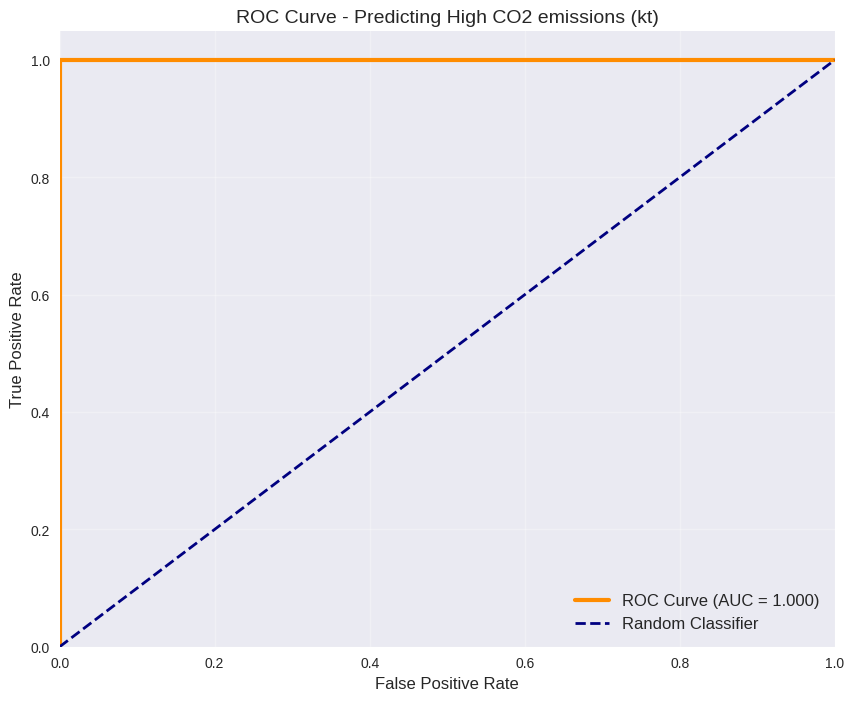

🎯 AUC Score: 1.000
🎯 Model Accuracy: 1.000

🔥 Top 5 Most Important Features:
   CO2_per_GDP: 0.161
   CO2 emissions from liquid fuel consumption (kt): 0.124
   Electricity production from renewable sources, excluding hydroelectric (kWh): 0.111
   CO2 emissions (kt): 0.108
   CO2 emissions from solid fuel consumption (kt): 0.090


In [21]:
"""
=======
CELL 13
=======
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("📈 ROC CURVE ANALYSIS FOR CO2 CLASSIFICATION")
print("=" * 50)

# Create binary classification: High vs Low CO2 emissions
co2_threshold = df_clustered[main_feature].median()
y_binary = (df_clustered[main_feature] > co2_threshold).astype(int)

print(f"CO2 threshold: {co2_threshold:,.0f}")
print(f"High CO2 (1): {y_binary.sum()} entities")
print(f"Low CO2 (0): {(1-y_binary).sum()} entities")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.3, random_state=42
)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get probabilities for ROC curve
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2,
         linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - Predicting High {main_feature}', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"🎯 AUC Score: {roc_auc:.3f}")
print(f"🎯 Model Accuracy: {model.score(X_test, y_test):.3f}")

# Feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\n🔥 Top 5 Most Important Features:")
for _, row in feature_importance_df.head().iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.3f}")
